# Descriptive Statistics

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("heart_2022_no_nans.csv")

In [28]:
df.describe()

,PhysicalHealthDays,MentalHealthDays,SleepHours,HeightInMeters,WeightInKilograms,BMI
count,246022.000000,246022.000000,246022.000000,246022.000000,246022.000000,246022.000000
mean,4.119026,4.167140,7.021331,1.705150,83.615179,28.668136
std,8.405844,8.102687,1.440681,0.106654,21.323156,6.513973
min,0.000000,0.000000,1.000000,0.910000,28.120000,12.020000
25%,0.000000,0.000000,6.000000,1.630000,68.040000,24.270000
50%,0.000000,0.000000,7.000000,1.700000,81.650000,27.460000
75%,3.000000,4.000000,8.000000,1.780000,95.250000,31.890000
max,30.000000,30.000000,24.000000,2.410000,292.570000,97.650000


In [29]:
heart_attack_counts = df["HadHeartAttack"].value_counts()
print(heart_attack_counts)

heart_attack_percentages = (
    df["HadHeartAttack"]
    .value_counts(normalize=True)
    .mul(100)
)

print(heart_attack_percentages)

HadHeartAttack
No     232587
Yes     13435
Name: count, dtype: int64
HadHeartAttack
No     94.539106
Yes     5.460894
Name: proportion, dtype: float64


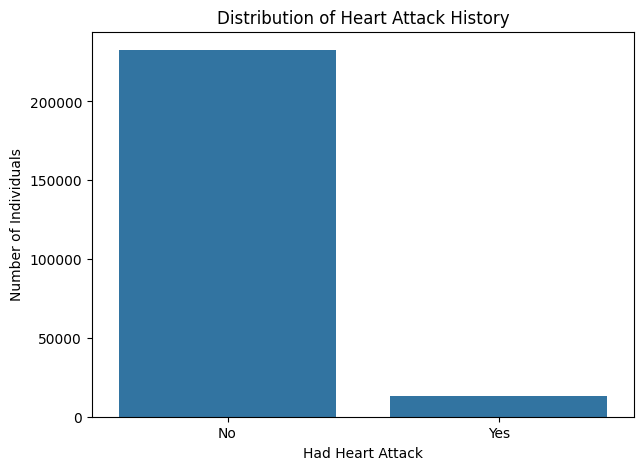

In [30]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="HadHeartAttack")

plt.title("Distribution of Heart Attack History")
plt.xlabel("Had Heart Attack")
plt.ylabel("Number of Individuals")
plt.show()

In [31]:
age_order = [
    "Age 18 to 24",
    "Age 25 to 29",
    "Age 30 to 34",
    "Age 35 to 39",
    "Age 40 to 44",
    "Age 45 to 49",
    "Age 50 to 54",
    "Age 55 to 59",
    "Age 60 to 64",
    "Age 65 to 69",
    "Age 70 to 74",
    "Age 75 to 79",
    "Age 80 or older"
]

age_counts = df["AgeCategory"].value_counts().reindex(age_order)

print(age_counts)

AgeCategory
Age 18 to 24       13122
Age 25 to 29       11109
Age 30 to 34       13346
Age 35 to 39       15614
Age 40 to 44       16973
Age 45 to 49       16753
Age 50 to 54       19913
Age 55 to 59       22224
Age 60 to 64       26720
Age 65 to 69       28557
Age 70 to 74       25739
Age 75 to 79       18136
Age 80 or older    17816
Name: count, dtype: int64


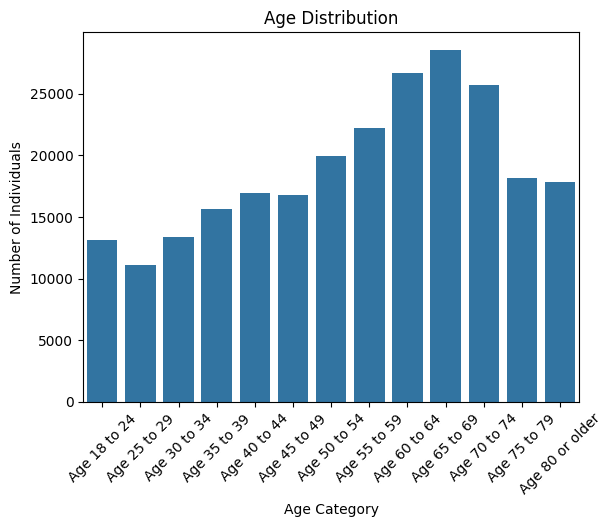

In [32]:
sns.countplot(
    data=df,
    x="AgeCategory",
    order=age_order
)

plt.title("Age Distribution")
plt.xlabel("Age Category")
plt.ylabel("Number of Individuals")
plt.xticks(rotation=45)
plt.show()

In [33]:
health_order = [
    "Poor",
    "Fair",
    "Good",
    "Very good",
    "Excellent"
]

health_counts = df["GeneralHealth"].value_counts().reindex(health_order)

print(health_counts)
print("\nPercentages:")
print((health_counts / len(df) * 100))

GeneralHealth
Poor          9430
Fair         30659
Good         77409
Very good    86999
Excellent    41525
Name: count, dtype: int64

Percentages:
GeneralHealth
Poor          3.832991
Fair         12.461894
Good         31.464259
Very good    35.362285
Excellent    16.878572
Name: count, dtype: float64


In [34]:
heart_attack_by_health = pd.crosstab(
    df["GeneralHealth"],
    df["HadHeartAttack"],
    normalize="index"
) * 100

print(heart_attack_by_health)

HadHeartAttack         No        Yes
GeneralHealth                       
Excellent       98.569536   1.430464
Fair            87.775205  12.224795
Good            94.058830   5.941170
Poor            78.536585  21.463415
Very good       97.160887   2.839113


In [35]:
health_conditions = [
    "HadAngina",
    "HadStroke",
    "HadAsthma",
    "HadCOPD",
    "HadDepressiveDisorder",
    "HadKidneyDisease",
    "HadArthritis",
    "HadDiabetes"
]

condition_summary = []

for column in health_conditions:
    yes_count = (df[column] == "Yes").sum()
    yes_percentage = yes_count / len(df) * 100
    
    condition_summary.append({
        "Condition": column,
        "Count": yes_count,
        "Percentage": yes_percentage
    })

condition_summary = pd.DataFrame(condition_summary)

condition_summary["Percentage"] = (
    condition_summary["Percentage"]
)

condition_summary

,Condition,Count,Percentage
0,HadAngina,14953,6.077912
1,HadStroke,10112,4.110202
2,HadAsthma,36529,14.847859
3,HadCOPD,18994,7.720448
4,HadDepressiveDisorder,50620,20.575396
5,HadKidneyDisease,11284,4.586582
6,HadArthritis,84883,34.502199
7,HadDiabetes,33813,13.743893


In [36]:
smoker_counts = df["SmokerStatus"].value_counts()

print(smoker_counts)
print("\nPercentages:")
print((smoker_counts / len(df) * 100))

SmokerStatus
Never smoked                             147737
Former smoker                             68527
Current smoker - now smokes every day     21659
Current smoker - now smokes some days      8099
Name: count, dtype: int64

Percentages:
SmokerStatus
Never smoked                             60.050321
Former smoker                            27.854013
Current smoker - now smokes every day     8.803684
Current smoker - now smokes some days     3.291982
Name: count, dtype: float64


In [37]:
physical_activity = (
    df["PhysicalActivities"]
    .value_counts(normalize=True)
    .mul(100)
)

print(physical_activity)

PhysicalActivities
Yes    77.76459
No     22.23541
Name: proportion, dtype: float64
